In [1]:
# Load a data file
import os
from ipywidgets import interact
from ipywidgets import widgets, interactive
from IPython.display import display

import sys
sys.path.append('/home/geonkim/mixed_states')
from plotting import *

file_list = os.listdir('./txt/')
dirname  = os.path.basename(os.getcwd())

iter = 40524

Nx1 = 180
Nx2 = Nx1
SUBn = 10
PTOn = 9
STOn = 20
N_L = 2
CAPn = STOn + 3

T0 = str('300K')
e_f = str('WR, {} iters'.format(iter))


file_list = [file for file in file_list if file.startswith(f'NOrderParam_{dirname}{iter:05d}')]
file = file_list[0]
print(file)
txt = './txt/'+ file

NOrderParam_0.4grid_180uc_2L_WR_300K_PTO9STO20_gen_3d_40524.txt


In [2]:
#Reading data
from matplotlib_inline.backend_inline import set_matplotlib_formats

# SVG 형식으로 설정
set_matplotlib_formats('png')




# Nx3 = SUBn + 1 + (2+PTOn+STOn) * N_L + CAPn
Nx3 = 74

dx1 = 0.4
dx3 = 0.4
le0 = ( 1.73e-10 / (abs(3.8 * ( 298 - 752 ) * 1e5) )) ** 0.5 

t0 = 0.1e-12
dt = 0.5* t0


vxmin = 0 
vxmax = Nx1 * dx1
vymin = 0
vymax = Nx3 * dx3

X, Y, Z = np.meshgrid(np.arange(0, Nx1) * dx1 * le0 * 1e9,\
                      np.arange(0, Nx2) * dx1 * le0 * 1e9,\
                      np.arange(0, Nx3) * dx3 * le0 * 1e9 , indexing='ij')

Dx =  D_periodic(Nx1) / 2 / dx1 / le0
Dy =  D_periodic(Nx2) / 2 / dx1 / le0
Dz_neu = D_neuman(Nx3) / 2 / dx3 / le0


Ix = np.identity(Nx1)
Iy = np.identity(Nx2)
Iz = np.identity(Nx3)


P1p0, P2p0, P3p0, P1, P2, P3, u1p0, u2p0, u3p0,\
u1p1, u2p1, u3p1, e11p1, e22p1,e33p1, e12p1, e13p1,e23p1,\
E1, E2, E3, f_bulk, f_E1, f_E2, f_E3, f_gradient,\
f_electric, f_sum = readOrder(txt)

corresponding_file = txt.replace('NOrderParam', 'NFreeEnergy')
FE_arr = np.loadtxt(corresponding_file)

FE_bulk = FE_arr[:,0]
FE_E1= FE_arr[:,1]
FE_E2= FE_arr[:,2]
FE_E3= FE_arr[:,3]
FE_grad= FE_arr[:,4]
FE_elec= FE_arr[:,5]
FE_sum= FE_arr[:,6]

print('dOnE')


dOnE


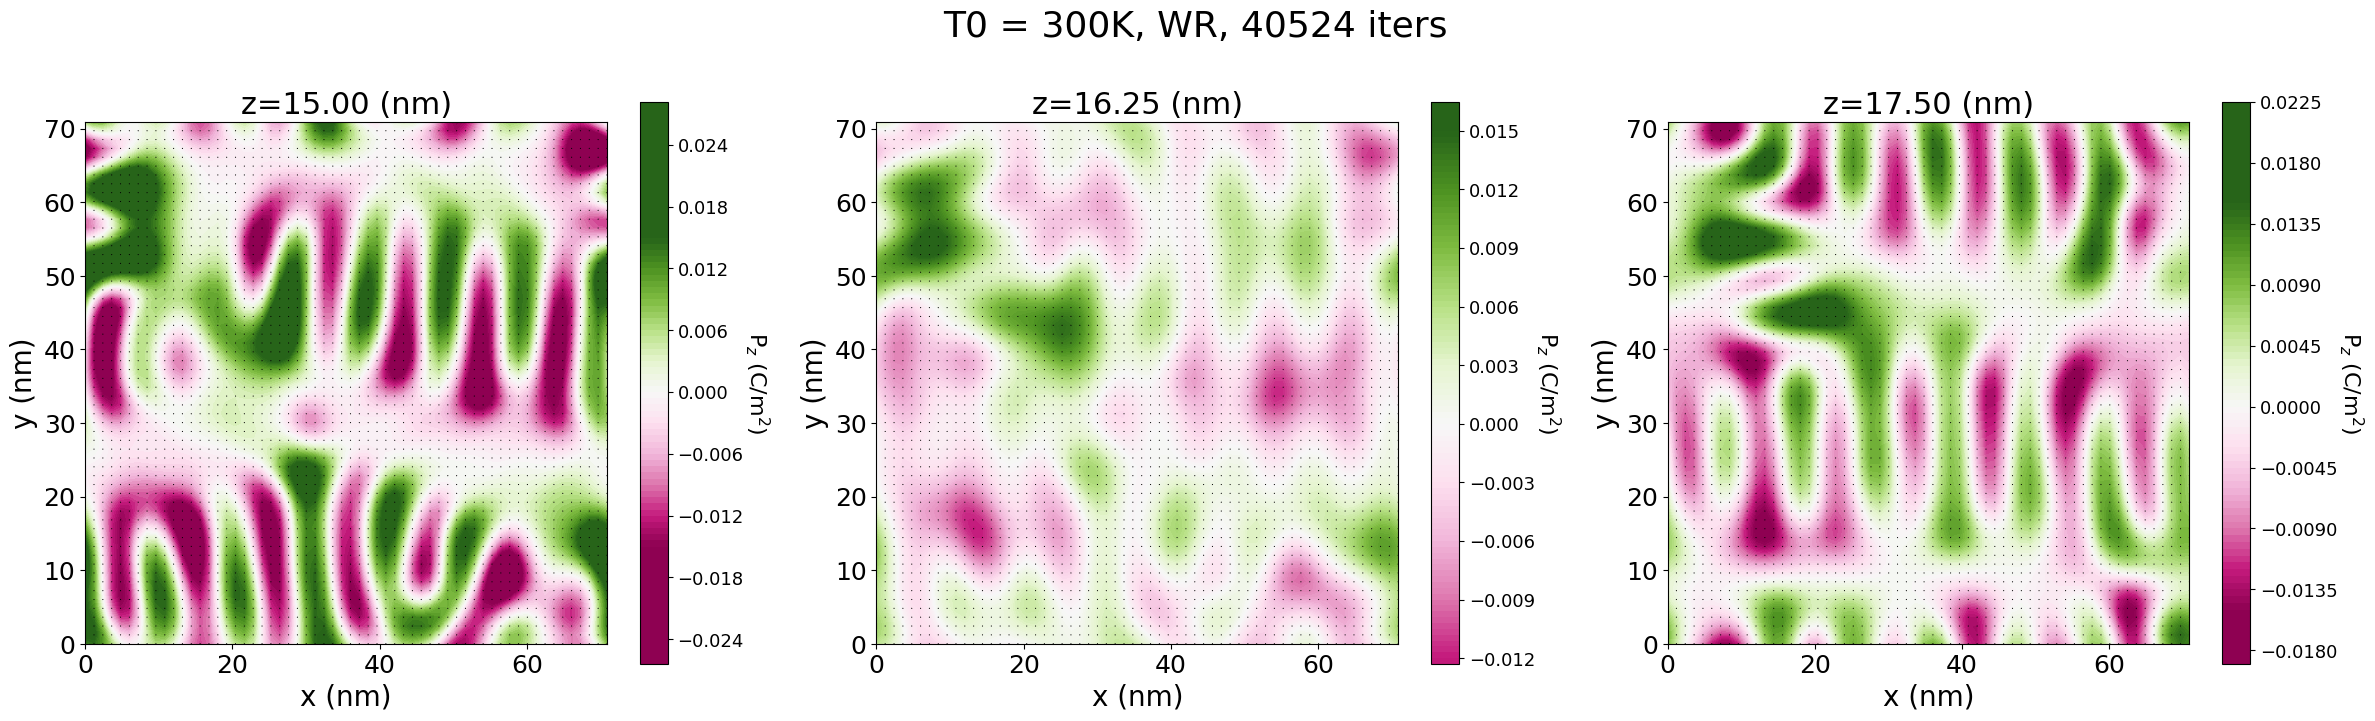

In [3]:
plot_result_pol_XY_multi( P1, P2, P3, X, Y, Nx1, Nx2, Nx3,\
                         [15, 16.25, 17.5], dx3, T0, e_f, step=3, headwidth=3, headlength=3, headaxislength=4, scale=30, colorscale=0.015) 

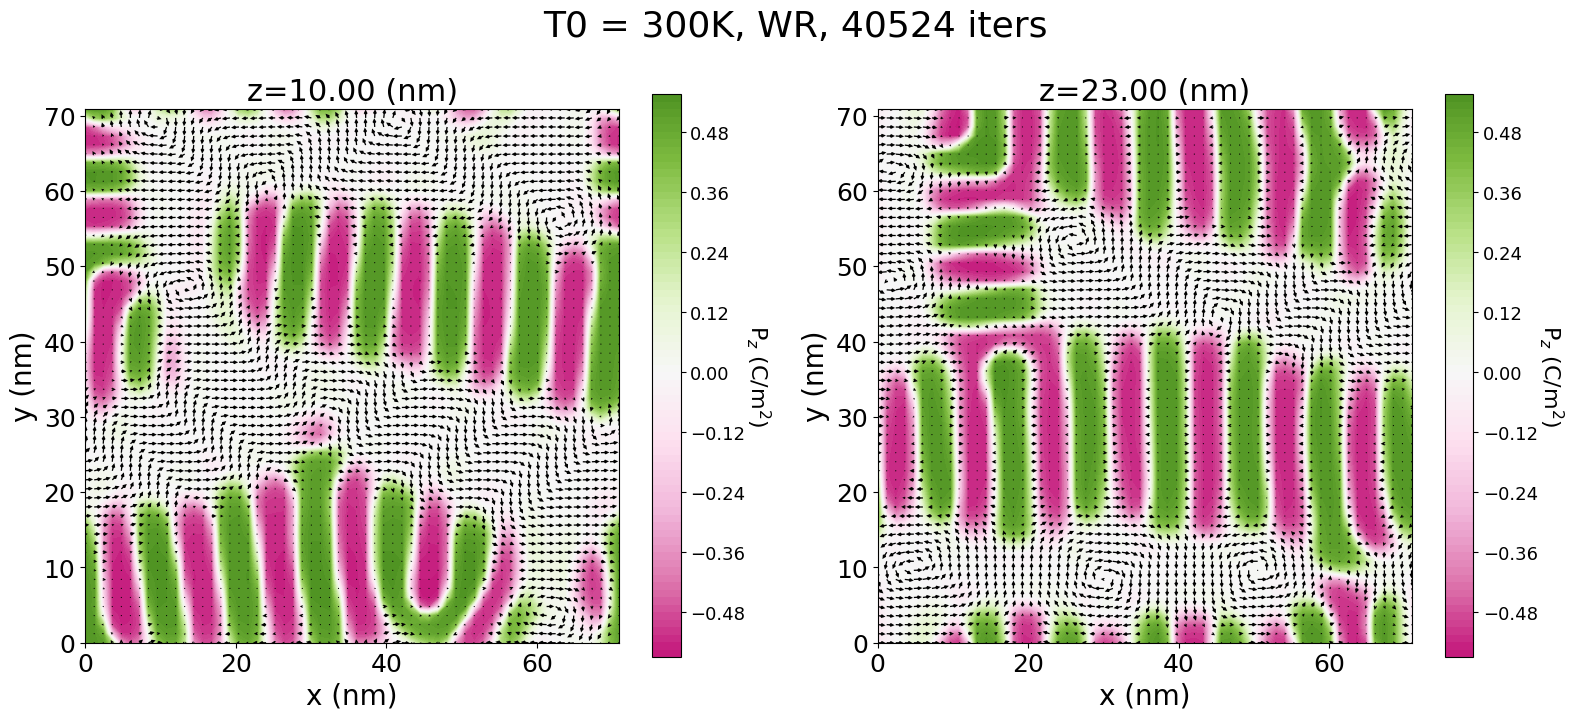

In [4]:
plot_result_pol_XY_multi( P1, P2, P3, X, Y, Nx1, Nx2, Nx3,\
                         [10, 23], dx3, T0, e_f, step=3, headwidth=3, headlength=3, headaxislength=4, scale=30, colorscale=0.7) 

In [ ]:
# Polarization (with silders)

Dx1_slider = widgets.FloatSlider(value=4, min=0, max=Nx1*dx1, step=0.1, description='Dx1:')
Dx2_slider = widgets.FloatSlider(value=0, min=0, max=Nx2*dx1, step=0.1, description='Dx2:')
Dx3_slider = widgets.FloatSlider(value=10, min=0, max=Nx3*dx3, step=0.1, description='Dx3:')
step_slider = widgets.FloatSlider(value=3, min=1, max=8, step=1, description='step:')
colorscale_slider = widgets.FloatSlider(value=0.7, min=0.01, max=2, step=0.05, description='colorscale:')
scale_slider = widgets.FloatSlider(value=30, min=2, max=75, step=0.05, description='scale:')

interact(plot_result_pol, 
         A1=widgets.fixed(P1), A2=widgets.fixed(P2), A3=widgets.fixed(P3),  
         X=widgets.fixed(X), Y=widgets.fixed(Y), Z=widgets.fixed(Z), 
         Nx1=widgets.fixed(Nx1), Nx2=widgets.fixed(Nx2), Nx3=widgets.fixed(Nx3), 
         freeE=widgets.fixed(FE_sum[:iter]), 
         Dx1=Dx1_slider, Dx2=Dx2_slider, Dx3=Dx3_slider, dx1=widgets.fixed(dx1), dx2=widgets.fixed(dx1), dx3=widgets.fixed(dx3), 
         le0 = widgets.fixed(le0), file=widgets.fixed(file),
         vxmin = widgets.fixed(vxmin), vxmax = widgets.fixed(vxmax), vymin = widgets.fixed(vymin), vymax = widgets.fixed(vymax),
         T0 = widgets.fixed(T0), e_f = widgets.fixed(e_f), step = step_slider, scale = scale_slider, colorscale = colorscale_slider)

interactive(children=(FloatSlider(value=4.0, description='Dx1:', max=72.0), FloatSlider(value=0.0, description…

<function plotting.plot_result_pol(A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3, freeE, Dx1, Dx2, Dx3, dx1, dx2, dx3, le0, file, vxmin, vxmax, vymin, vymax, T0, e_f, step, scale, colorscale)>

In [6]:
a = int(iter)

/tmp/ipykernel_1291446/204894474.py:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('png')


[-2.8476642530853262e-08, 2.7866224933492047e-07, 9.191075703031605e-08, 6.191943910114706e-07, 9.998780634976012e-07, 6.11573202924092e-07, -3.410543116631209e-07]


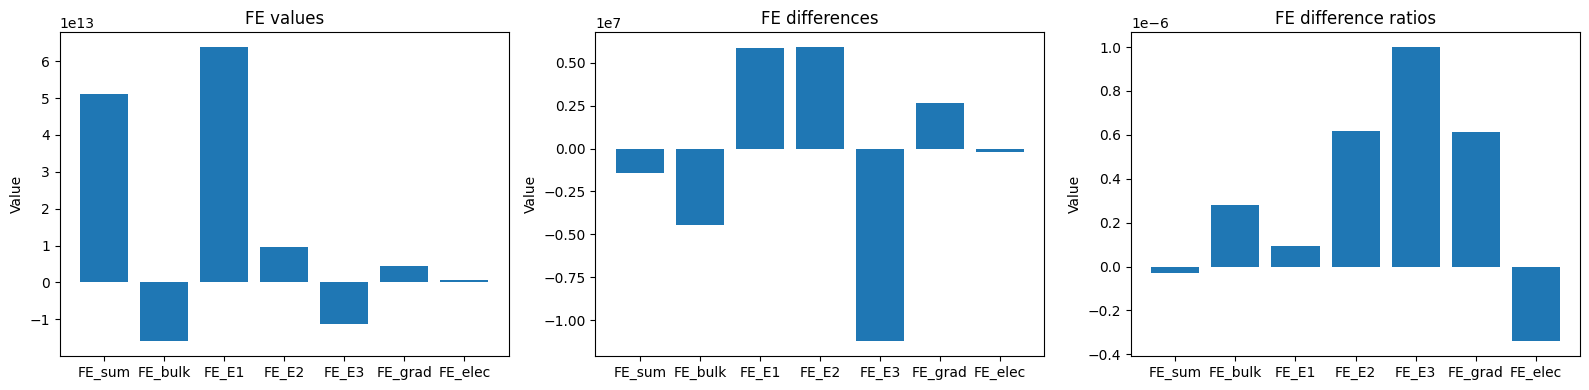

In [7]:
#Free energy 그래프

import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats

# SVG 형식으로 설정
set_matplotlib_formats('png')



data1 = [FE_sum[a], FE_bulk[a], FE_E1[a], FE_E2[a], FE_E3[a], FE_grad[a], FE_elec[a]]
data2 = [(FE_sum[a] - FE_sum[a-1]),
         (FE_bulk[a] - FE_bulk[a-1]),
         (FE_E1[a] - FE_E1[a-1]),
         (FE_E2[a] - FE_E2[a-1]),
         (FE_E3[a] - FE_E3[a-1]),
         (FE_grad[a] - FE_grad[a-1]),
         (FE_elec[a] - FE_elec[a-1])]
data3 = [(FE_sum[a] - FE_sum[a-1]) / FE_sum[a],
         (FE_bulk[a] - FE_bulk[a-1]) / FE_bulk[a],
         (FE_E1[a] - FE_E1[a-1]) / FE_E1[a],
         (FE_E2[a] - FE_E2[a-1]) / FE_E2[a],
         (FE_E3[a] - FE_E3[a-1]) / FE_E3[a],
         (FE_grad[a] - FE_grad[a-1]) / FE_grad[a],
         (FE_elec[a] - FE_elec[a-1]) / FE_elec[a]]

print(data3)

# x축 값을 1부터 7까지로 설정
x_values = ('FE_sum', 'FE_bulk', 'FE_E1', 'FE_E2', 'FE_E3', 'FE_grad', 'FE_elec')

# 하나의 figure에 세 개의 subplot 생성
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# 첫 번째 subplot
axs[0].bar(x_values, data1)
axs[0].set_title('FE values')
#axs[0].set_xlabel('Index')
axs[0].set_ylabel('Value')

# 두 번째 subplot
axs[1].bar(x_values, data2)
axs[1].set_title('FE differences')
#axs[1].set_xlabel('Index')
axs[1].set_ylabel('Value')

# 세 번째 subplot
axs[2].bar(x_values, data3)
axs[2].set_title('FE difference ratios')
#axs[2].set_xlabel('Index')
axs[2].set_ylabel('Value')

# 레이아웃 조정
plt.tight_layout()

# 그래프 보여주기
plt.show()


In [11]:
E1_sliced = E1.reshape(Nx1, Nx2, Nx3)[:,:,31:51]
E2_sliced = E2.reshape(Nx1, Nx2, Nx3)[:,:,31:51]
E3_sliced = E3.reshape(Nx1, Nx2, Nx3)[:,:,31:51]

In [9]:
def plot_result_electric( A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3, dx1, dx2, dx3, file, le0, T0, e_f, step, scale, colorscale):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    fig, ax = plt.subplots(2,2, figsize = (24,18))
    
    step = int(step)
    # X_sparse = X[:,:,Nz_plot].T[::step, ::step]
    # Y_sparse = Y[:,:,Nz_plot].T[::step, ::step]
    # Z_sparse = Z[:,:,Nz_plot].T[::step, ::step]
    # A1_sparse = A1_plot[:,:,Nz_plot].T[::step, ::step]
    # A2_sparse = A2_plot[:,:,Nz_plot].T[::step, ::step]
    # A3_sparse = A3_plot[:,:,Nz_plot].T[::step, ::step]
    
    c1 = ax[0][0].contourf(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A1_plot[Nx_plot,:, :].T[::step, ::step], 50, cmap = 'PiYG')
    c1.set_clim(-colorscale, colorscale)
    plt.colorbar(c1,ax=ax[0][0] )
    ax[0][0].quiver(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A2_plot[Nx_plot,:, :].T[::step, ::step], A3_plot[Nx_plot,:, :].T[::step, ::step], scale = scale)
    
    
    
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    # ax[0][0].set_ylim(13, 24)
    
    
    
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    
    
    c2 = ax[0][1].contourf(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A2_plot[:, Ny_plot,:].T[::step, ::step], 50, cmap = 'PiYG') # Nx2 = int(Nx2/2) plane
    c2.set_clim(-colorscale, colorscale)
    plt.colorbar(c2,ax=ax[0][1])
    ax[0][1].quiver(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A1_plot[:,Ny_plot,:].T[::step, ::step], A3_plot[:,Ny_plot,:].T[::step, ::step] , scale = scale)
    
    
    ax[0][1].tick_params(labelsize = 20)
    
    ax[0][1].set_xlabel(f'x (nm), y={Dx2}(nm)', size = 20)
    ax[0][1].set_ylabel('z (nm)', size = 20)
    
    c3 = ax[1][0].contourf( X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step],  A3_plot[:,:,Nz_plot].T[::step, ::step], 100, cmap = 'PiYG')  
    plt.colorbar(c3 ,ax=ax[1][0])
    c3.set_clim(-colorscale, colorscale)
    ax[1][0].quiver(X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step], A1_plot[:,:,Nz_plot].T[::step, ::step], A2_plot[:,:,Nz_plot].T[::step, ::step], scale = scale )
    
    
    
    ax[1][0].tick_params(labelsize = 20)
    ax[1][0].set_xlabel(f'x (nm), z={Dx3}(nm)',  size = 20)
    ax[1][0].set_ylabel('y (nm)', size = 20)
    ax[1][0].set_title(f'T0 = {T0}, {e_f}', size = 20)


    ax[1][1].plot(freeE[:int(iter)])
    ax[1][1].set_xlabel('The number of iteration', size = 20)
    ax[1][1].set_ylabel('Free energy', size = 20)
    ax[1][1].tick_params(labelsize = 20)    

4.006 nm 0.0 nm 4.006 nm


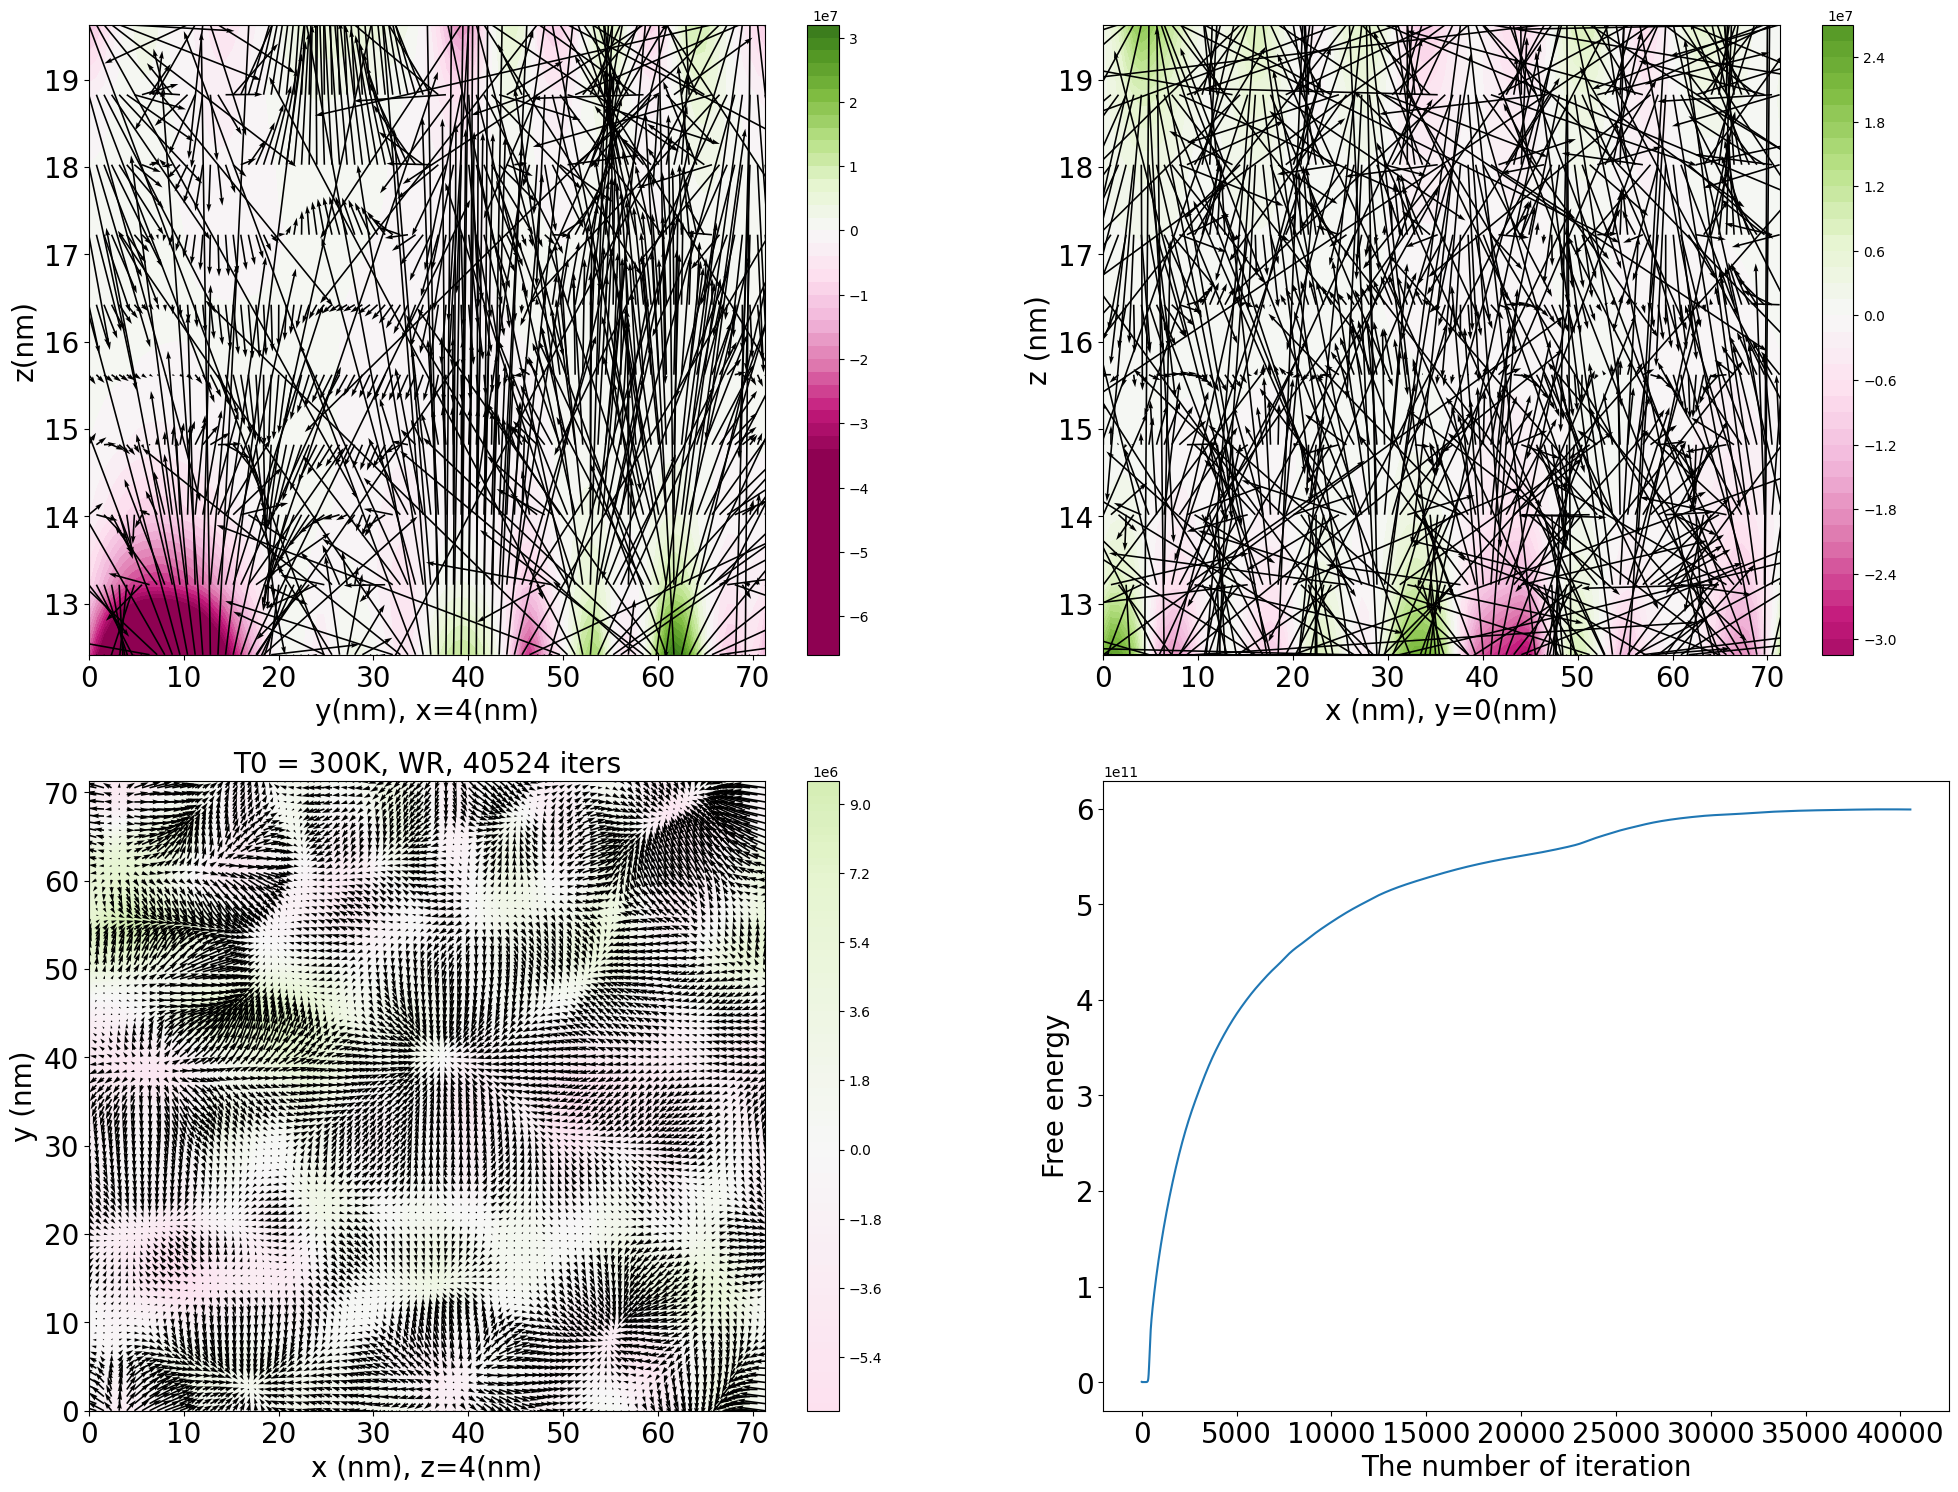

In [13]:
# 직접 값 입력
Dx1_val = 4
Dx2_val = 0
Dx3_val = 4
step_val = 2
scale_val = 5e7
colorscale_val = 3.5e7  # 사용하지 않음

# 함수 직접 호출
plot_result_electric(
    A1=E1_sliced.reshape(Nx1*Nx2*20), A2=E2_sliced.reshape(Nx1*Nx2*20), A3=E3_sliced.reshape(Nx1*Nx2*20),
    X=X[:,:,31:51], Y=Y[:,:,31:51], Z=Z[:,:,31:51],
    Nx1=Nx1, Nx2=Nx2, Nx3=20,
    freeE=FE_elec[:iter],
    Dx1=Dx1_val, Dx2=Dx2_val, Dx3=Dx3_val,
    dx1=dx1, dx2=dx1, dx3=dx3,
    file=file, le0=le0,
    T0=T0, e_f=e_f,
    step=step_val, scale=scale_val, colorscale=colorscale_val
)